In [22]:
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from scipy.special import expit  # sigmoid
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score
)
from sklearn.model_selection import train_test_split

In [23]:
df = pd.read_csv('../data/processed_data.csv')
print("Dataset shape:", df.shape)

# Separate features and target
y_raw = df['Attrition'].values
X = df.drop(columns=['Attrition']).values
y = (y_raw == y_raw.max()).astype(int)
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Original class distribution (real data):")
print(f"  No Attrition (0): {np.sum(y == 0)}")
print(f"  Attrition    (1): {np.sum(y == 1)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Test class distribution (real, untouched):")
print(f"  No Attrition (0): {np.sum(y_test == 0)}")
print(f"  Attrition    (1): {np.sum(y_test == 1)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {X_train.shape[0]} samples")
print(f"  No Attrition (0): {np.sum(y_train == 0)}")
print(f"  Attrition    (1): {np.sum(y_train_resampled == 1)}")

Dataset shape: (1470, 37)

Features shape: (1470, 36)
Original class distribution (real data):
  No Attrition (0): 1232
  Attrition    (1): 238

Train: 1176 samples | Test: 294 samples
Test class distribution (real, untouched):
  No Attrition (0): 246
  Attrition    (1): 48

After SMOTE — Train: 1176 samples
  No Attrition (0): 986
  Attrition    (1): 986


In [24]:
class MiniXGBClassifier:
    def __init__(
        self,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.learning_rate = learning_rate
        self.subsample = subsample
        self.colsample_bytree = colsample_bytree
        self.random_state = random_state
        self.trees = []
        self.base_score = None

    def fit(self, X, y):
        np.random.seed(self.random_state)

        n_samples, n_features = X.shape

        # เริ่มจาก log-odds
        pos_ratio = np.mean(y)
        self.base_score = np.log(pos_ratio / (1 - pos_ratio))

        # prediction เริ่มต้น
        y_pred = np.full(n_samples, self.base_score)

        for _ in range(self.n_estimators):

            # 1️⃣ คำนวณ probability
            prob = expit(y_pred)

            # 2️⃣ คำนวณ gradient (logloss derivative)
            gradient = y - prob

            # 3️⃣ Subsample rows
            row_idx = np.random.choice(
                n_samples,
                int(self.subsample * n_samples),
                replace=False
            )

            # 4️⃣ Subsample columns
            col_idx = np.random.choice(
                n_features,
                int(self.colsample_bytree * n_features),
                replace=False
            )

            X_sub = X[row_idx][:, col_idx]
            grad_sub = gradient[row_idx]

            # 5️⃣ Train tree บน gradient
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                random_state=self.random_state
            )

            tree.fit(X_sub, grad_sub)

            # 6️⃣ Update prediction
            update = tree.predict(X[:, col_idx])
            y_pred += self.learning_rate * update

            self.trees.append((tree, col_idx))

    def predict_proba(self, X):
        y_pred = np.full(X.shape[0], self.base_score)

        for tree, col_idx in self.trees:
            update = tree.predict(X[:, col_idx])
            y_pred += self.learning_rate * update

        prob = expit(y_pred)

        return np.column_stack((1 - prob, prob))
    
    def predict(self, X, threshold=0.5):
        prob = self.predict_proba(X)[:, 1]
        return (prob >= threshold).astype(int)


In [25]:
xgb_model = MiniXGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train_resampled, y_train_resampled)

y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.25).astype(int)

In [26]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
specificity = tn / (tn + fp)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy)
print("Specificity:", specificity)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[165  81]
 [  9  39]]

Accuracy: 0.6938775510204082
Specificity: 0.6707317073170732
ROC-AUC: 0.7942073170731707

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.67      0.79       246
           1       0.33      0.81      0.46        48

    accuracy                           0.69       294
   macro avg       0.64      0.74      0.62       294
weighted avg       0.85      0.69      0.73       294



In [27]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
specificity = tn / (tn + fp)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy)
print("Specificity:", specificity)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[165  81]
 [  9  39]]

Accuracy: 0.6938775510204082
Specificity: 0.6707317073170732
ROC-AUC: 0.7942073170731707

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.67      0.79       246
           1       0.33      0.81      0.46        48

    accuracy                           0.69       294
   macro avg       0.64      0.74      0.62       294
weighted avg       0.85      0.69      0.73       294




Risk Distribution:
Low Risk: 203
Medium Risk: 69
High Risk: 22


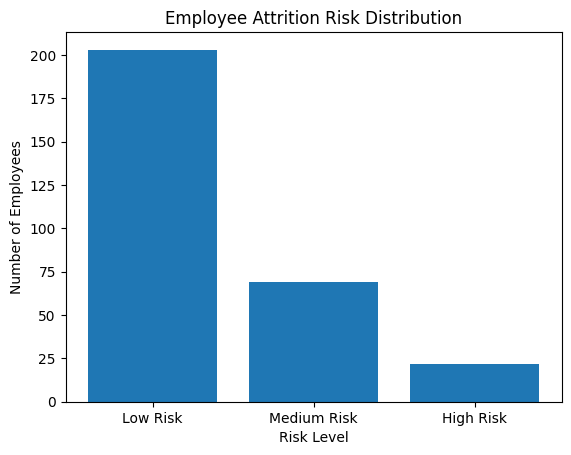

In [28]:
low_risk = np.sum(y_prob < 0.3)
medium_risk = np.sum((y_prob >= 0.3) & (y_prob < 0.6))
high_risk = np.sum(y_prob >= 0.6)

print("\nRisk Distribution:")
print("Low Risk:", low_risk)
print("Medium Risk:", medium_risk)
print("High Risk:", high_risk)


# -------------------------
# 7) Graph (Single Plot)
# -------------------------
categories = ["Low Risk", "Medium Risk", "High Risk"]
values = [low_risk, medium_risk, high_risk]

plt.figure()
plt.bar(categories, values)
plt.title("Employee Attrition Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Number of Employees")
plt.show()

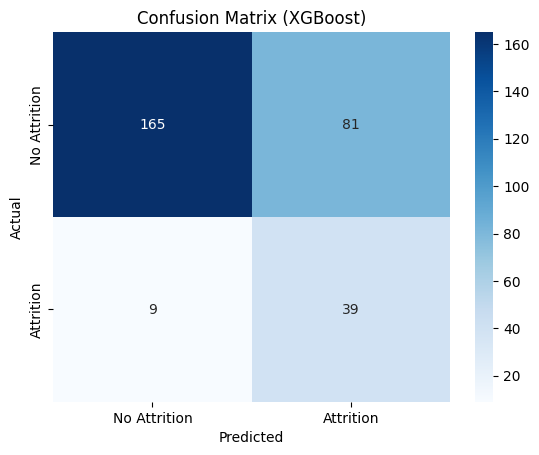

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)

plt.title("Confusion Matrix (XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

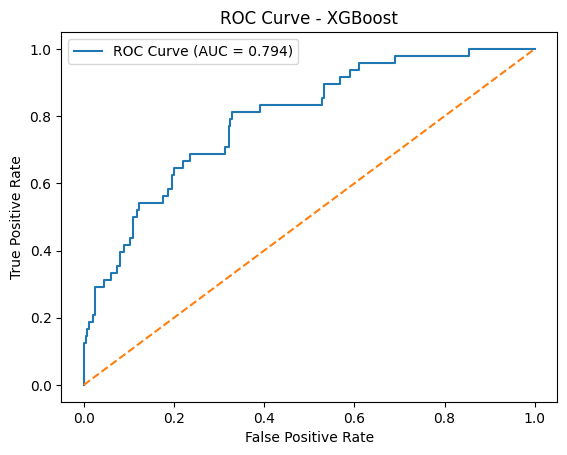

In [30]:
from sklearn.metrics import roc_curve

# -------------------------
# ROC Curve
# -------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random guess line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()


In [31]:
from xgboost import XGBClassifier

In [32]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

In [33]:
xgb_model.fit(X_train_resampled, y_train_resampled)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [34]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.25).astype(int)


Confusion Matrix:
[[214  32]
 [ 21  27]]

Accuracy: 0.8197278911564626
Specificity: 0.8699186991869918
ROC-AUC: 0.8210535230352304

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       246
           1       0.46      0.56      0.50        48

    accuracy                           0.82       294
   macro avg       0.68      0.72      0.70       294
weighted avg       0.84      0.82      0.83       294



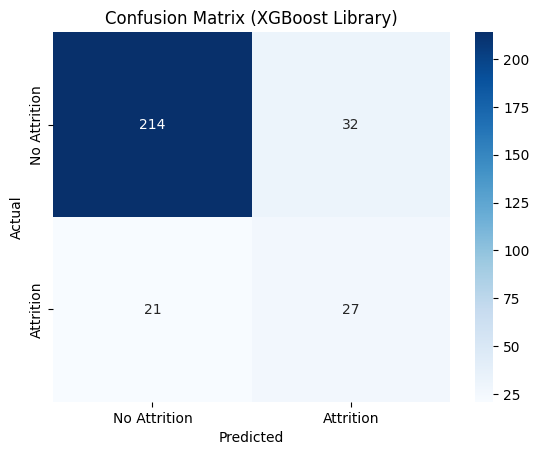

In [35]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)
specificity = tn / (tn + fp)

print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy)
print("Specificity:", specificity)
print("ROC-AUC:", roc_auc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure()
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.title("Confusion Matrix (XGBoost Library)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


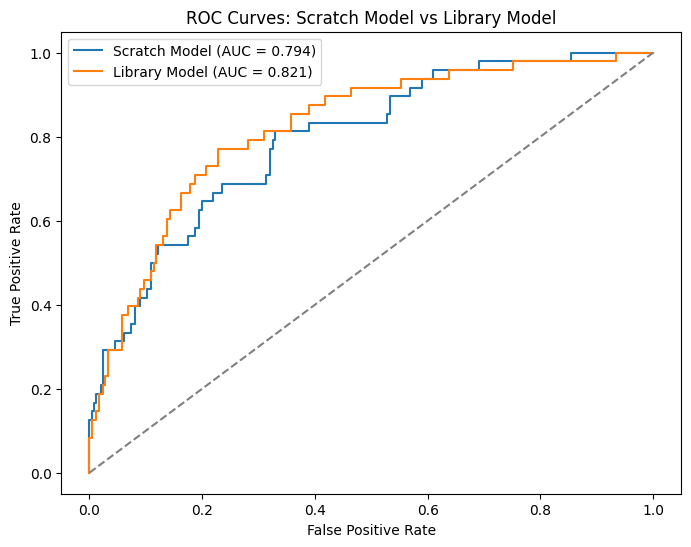

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

# Refit scratch model to get probabilities
mini_xgb = MiniXGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
mini_xgb.fit(X_train_resampled, y_train_resampled)
y_prob_scratch = mini_xgb.predict_proba(X_test)[:, 1]

# Compute ROC for scratch model
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, y_prob_scratch)
roc_auc_scratch = roc_auc_score(y_test, y_prob_scratch)

# Compute ROC for library model (using existing y_prob)
fpr_lib, tpr_lib, _ = roc_curve(y_test, y_prob)
roc_auc_lib = roc_auc_score(y_test, y_prob)

# Plot both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_scratch, tpr_scratch, label=f'Scratch Model (AUC = {roc_auc_scratch:.3f})')
plt.plot(fpr_lib, tpr_lib, label=f'Library Model (AUC = {roc_auc_lib:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Scratch Model vs Library Model')
plt.legend()
plt.show()